In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(40,95) # 40부터 95까지의 정수 중 하나를 무작위 선택 반환

73

In [10]:
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# data

In [11]:
# 여자
for female in data[:100:2]:
    print(female, end=' ')
# 남자
print('\n---------------------------------')
for male in data[1:100:2]:
    print(male, end=' ')

[66, 168] [63, 146] [70, 160] [61, 141] [60, 168] [68, 153] [47, 161] [48, 142] [67, 144] [63, 144] [55, 145] [53, 150] [59, 166] [60, 154] [69, 170] [68, 162] [44, 153] [47, 150] [51, 151] [43, 151] [55, 152] [46, 152] [56, 147] [68, 140] [64, 153] [52, 164] [53, 150] [66, 143] [40, 143] [68, 150] [53, 167] [57, 156] [67, 159] [61, 168] [58, 140] [46, 140] [60, 157] [45, 160] [40, 167] [70, 168] [48, 157] [54, 170] [69, 161] [51, 150] [63, 168] [52, 146] [62, 147] [51, 155] [66, 162] [55, 167] 
---------------------------------
[73, 177] [67, 168] [67, 167] [78, 177] [72, 167] [62, 195] [77, 178] [71, 161] [86, 181] [87, 191] [73, 192] [89, 180] [89, 186] [83, 161] [70, 175] [64, 187] [81, 187] [75, 188] [64, 171] [89, 185] [85, 172] [94, 160] [79, 176] [68, 170] [62, 166] [60, 177] [86, 177] [62, 172] [77, 183] [82, 194] [72, 183] [72, 177] [72, 169] [95, 180] [72, 173] [94, 160] [95, 192] [84, 172] [88, 176] [62, 172] [82, 163] [84, 173] [77, 161] [88, 169] [95, 193] [90, 188] [79, 

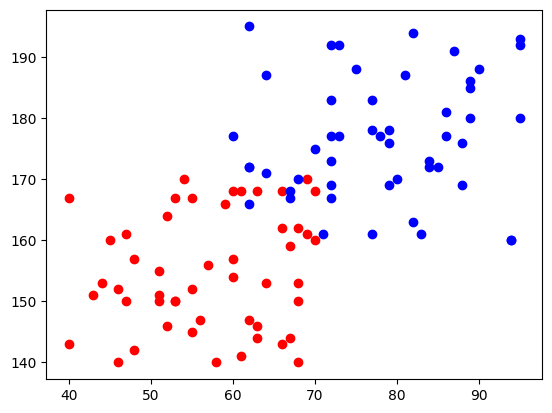

In [18]:
# print('여자 몸무게 :',[d[0] for d in data[::2]])
# print('여자 키 :',    [d[1] for d in data[::2]])
# print('남자 몸무게 :',[d[0] for d in data[1::2]])
# print('남자 키 :',    [d[1] for d in data[1::2]])
# for d in data[::2]:
#     plt.plot(d[0], d[1], 'o', color='r')
plt.plot([d[0] for d in data[::2]],
        [d[1] for d in data[::2]], 'o', color='r')
plt.plot([d[0] for d in data[1::2]],
        [d[1] for d in data[1::2]], 'o', color='b')

# 2. 군집화 로직

In [22]:
# 초기 랜덤지점 2개
random_points = [[random.randint(40, 95), random.randint(140, 195)],
                [random.randint(40, 95), random.randint(140, 195)]]
random_points

[[93, 169], [54, 163]]

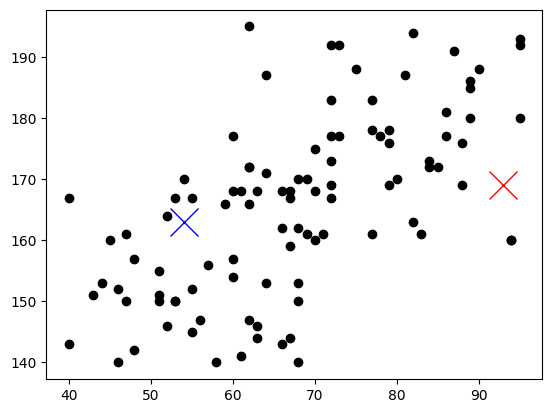

In [23]:
plt.plot([d[0] for d in data],
        [d[1] for d in data], 'o', color='k')
plt.plot(random_points[0][0],
         random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
         random_points[1][1], 'x', color='b', markersize=20) # 기준점2

In [24]:
# 두 점의 거리를 return (0,0) ~ (4,3)
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )

In [25]:
a = [0, 0]; b = [4, 3]
dist(a, b)

5.0

In [26]:
# 두 영역(random_points[0]과 random_points[1]을 기준으로 나눈 두 영역)
group1 = [] # random_points[0]이 가까운 그룹
group2 = [] # random_points[1]이 가까운 그룹
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group1.append(d) # 빨간 X랑 더 가까운 그룹
    else:
        group2.append(d) # 파란 X랑 더 가까운 그룹
len(group1), len(group2)

(35, 65)

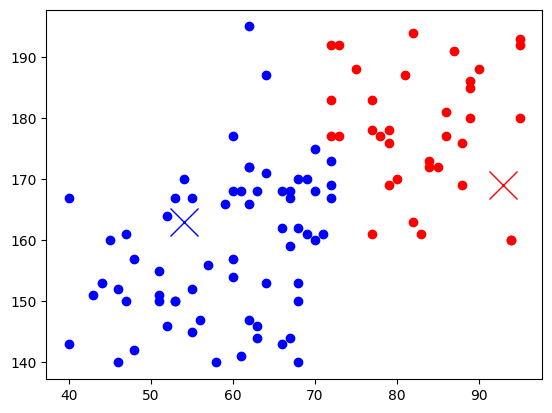

In [29]:
# 새로운 그룹 group1과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0],
        random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
        random_points[1][1], 'x', color='b', markersize=20) # 기준점2
plt.show()

In [30]:
# 기준점 이동 group1의 중심점, group2중심점
sumX=0 ; sumY=0
for g in group1:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점으로 할당
random_points[0] = [sumX/len(group1), sumY/len(group1)]
sumX=0 ; sumY=0
for g in group2:
    sumX += g[0]
    sumY += g[1]
# 새로운 기준점
random_points[1] = [sumX/len(group2), sumY/len(group2)]
random_points

[[83.11428571428571, 178.31428571428572],
 [59.276923076923076, 158.8923076923077]]

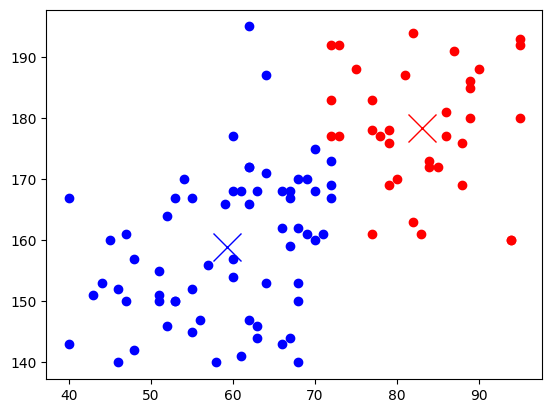

In [31]:
# 새로운 그룹 group1과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_points[0][0],
        random_points[0][1], 'x', color='r', markersize=20) # 기준점1
plt.plot(random_points[1][0],
        random_points[1][1], 'x', color='b', markersize=20) # 기준점2
plt.show()

# 3. 전체 코드(for문이용)
- data 생성
- 랜덤포인트2지점
- for문
    - 랜덤포인트 2지점기준으로 2개 group1과 group2
    - 랜덤포인트 이용(group1중간점, group2중간점)

초기 points :  [[78, 181], [58, 190]]
1 번째 points :  [[73.71428571428571, 168.74603174603175], [51.972972972972975, 165.0810810810811]]
2 번째 points :  [[76.46428571428571, 177.46428571428572], [51.93181818181818, 154.5681818181818]]
3 번째 points :  [[77.58, 180.82], [53.76, 153.96]]
4 번째 points :  [[77.95833333333333, 181.54166666666666], [54.32692307692308, 154.32692307692307]]
5 번째 points :  [[78.1063829787234, 181.93617021276594], [54.64150943396226, 154.49056603773585]]
6 번째 points :  [[78.1063829787234, 181.93617021276594], [54.64150943396226, 154.49056603773585]]
7 번째 points :  [[78.1063829787234, 181.93617021276594], [54.64150943396226, 154.49056603773585]]
8 번째 points :  [[78.1063829787234, 181.93617021276594], [54.64150943396226, 154.49056603773585]]
9 번째 points :  [[78.1063829787234, 181.93617021276594], [54.64150943396226, 154.49056603773585]]
10 번째 points :  [[78.1063829787234, 181.93617021276594], [54.64150943396226, 154.49056603773585]]


(140.0, 195.0)

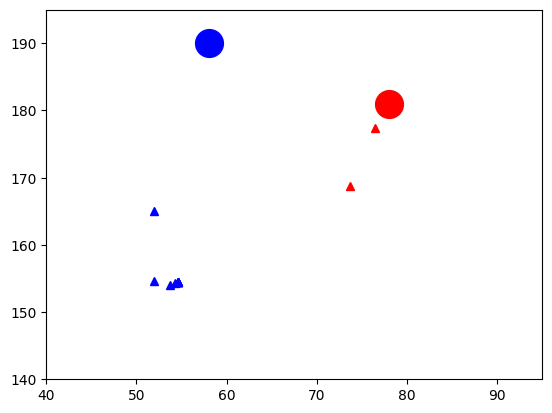

In [53]:
# 데이터 생성
data = []
for i in range(50):
    # 여자 데이터
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# point 지정
points = [[random.randint(40,95), random.randint(140,195)],
          [random.randint(40,95), random.randint(140,195)]]
print("초기 points : ", points)
plt.plot(points[0][0], points[0][1], 'o', c='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', c='b', markersize=20)
# 포인트 2지점기준으로 group1과 group2
for i in range(1, 11):
    group1 = [] # points[0]과 가까운 그룹
    group2 = [] # points[1]과 가까운 그룹
    for d in data:
        if dist(d, points[0]) < dist(d, points[1]):
            group1.append(d)
        else:
            group2.append(d)
    # 새로운 포인트로 할당
    sumX = 0; sumY=0
    for g in group1:
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX/len(group1), sumY/len(group1)]
    sumX = 0; sumY=0
    for g in group2:
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX/len(group2), sumY/len(group2)]
    print(i, "번째 points : ", points)
    plt.plot(points[0][0], points[0][1], '^', c='r')
    plt.plot(points[1][0], points[1][1], '^', c='b')
plt.xlim([40,95])
plt.ylim([140,195])

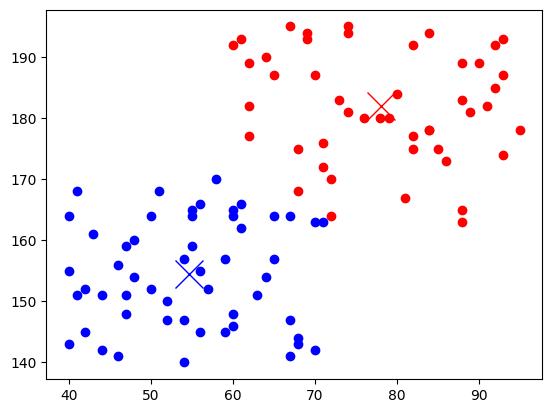

In [54]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝
    * 예측모델
        ; 분류, 회귀, 군집분석
        fit(학습), predict(예측)
    * 변환모델
        ; 전처리 ex. 스케일조정
        fit(학습), transform(변환함수)

In [55]:
# 군집분석 라이브러리가 joblib충돌 경고 메세지 출력
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [56]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠
              init='random', # 초기 중심점 랜덤하게
              n_init=10, # 10번 실행
              random_state=7)
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [57]:
# 중심점
model.cluster_centers_

array([[ 78.10638298, 181.93617021],
       [ 54.64150943, 154.49056604]])

In [58]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [59]:
group1 = data[model.labels_==1]
group2 = data[model.labels_==0]
c1, c2 = model.cluster_centers_

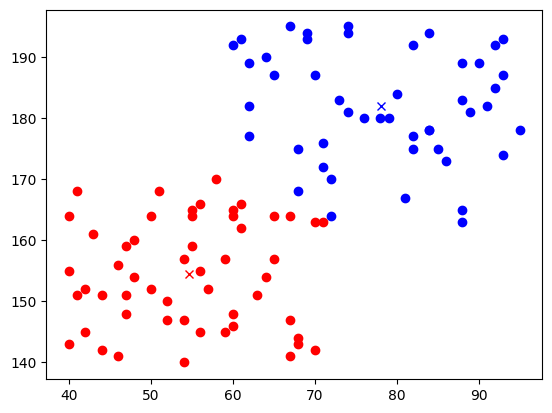

In [60]:
plt.plot([d[0] for d in group1],
         [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
         [d[1] for d in group2], 'o', color='b')
plt.plot(c1[0], c1[1], 'x', color='b') # group2의 중심점
plt.plot(c2[0], c2[1], 'x', color='r') # group2의 중심점